In [ ]:
import pandas as pd
import numpy as np

In [18]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt

In [21]:
def compute_all_metrics(
    y_true: np.ndarray,
    y_score: np.ndarray,
    top_k: int = 100,
    cutoff: float = 0.5,
) -> dict[str, float]:
    """Compute a full suite of classification metrics."""
    pred = (y_score >= cutoff).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    from sklearn.metrics import auc as sk_auc
    return {
        "AUROC": float(sk_auc(fpr, tpr)),
        "AUPR": float(sk_auc(rec, prec)),
        "AP": float(average_precision_score(y_true, y_score)),
        f"Recall@{top_k}": recall_at_k(y_true, y_score, top_k),
        f"Precision@{top_k}": precision_at_k(y_true, y_score, top_k),
        "Accuracy": float(accuracy_score(y_true, pred)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
    }

def precision_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> float:
    top_k = np.argsort(y_score)[::-1][:k]
    return float(np.sum(y_true[top_k]) / k) if k > 0 else 0.0


def recall_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> float:
    top_k = np.argsort(y_score)[::-1][:k]
    total = np.sum(y_true)
    return float(np.sum(y_true[top_k]) / total) if total > 0 else 0.0


In [38]:
from pathlib import Path
def plot_roc_pr(
    y_true: np.ndarray,
    y_score: np.ndarray,
    save_path: str | Path | None = None,
) -> None:
    """Plot ROC and Precision-Recall curves side by side."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    from sklearn.metrics import auc as sk_auc
    roc_auc = sk_auc(fpr, tpr)
    pr_auc = sk_auc(rec, prec)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax1.set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
    ax1.legend()

    ax2.plot(rec, prec, label=f"AP = {pr_auc:.4f}")
    ax2.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
    ax2.legend()

    fig.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close(fig)

In [4]:
heldout_direc = "~/DeepSLP/outputs/external_val/external_val_cv4/"

In [6]:
df_ens_pred = pd.read_csv(heldout_direc + "ensemble_predictions.tsv", sep='\t')

In [10]:
df_ens_pred[df_ens_pred['Query']=='MTOR']

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,predict_proba
61,A1BG,MTOR,-0.094861,0.850521,NaN,NaN,0,0,0,0,0,0,0.086575
179,A1CF,MTOR,-0.083701,0.984771,NaN,NaN,0,0,0,0,0,0,0.096408
297,A2M,MTOR,0.296972,0.503213,NaN,NaN,0,0,0,0,0,0,0.100681
415,A2ML1,MTOR,0.104500,0.785691,NaN,NaN,0,0,0,0,0,0,0.126972
533,A3GALT2,MTOR,0.095012,0.908000,NaN,NaN,0,0,0,0,0,0,0.089841
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574658,ZYG11A,MTOR,0.088709,0.932267,NaN,NaN,0,0,0,0,0,0,0.118014
1574659,ZYG11B,MTOR,-0.027329,0.990031,NaN,NaN,0,0,0,0,0,0,0.120712
1574660,ZYX,MTOR,0.146266,0.842548,NaN,NaN,0,0,0,0,0,0,0.042655
1574661,ZZEF1,MTOR,0.169984,0.893095,NaN,NaN,0,0,0,0,0,0,0.104478


In [16]:
df_ens_pred_MTOR = df_ens_pred[df_ens_pred['Query']=='MTOR']

In [29]:
df_ens_pred_MTOR.reset_index(inplace=True, drop=True)


In [30]:
df_ens_pred_MTOR['predict_proba'].nlargest(100)

816      0.333285
2591     0.331692
16239    0.331272
11238    0.328550
13080    0.320667
           ...   
13082    0.213542
16757    0.213108
12897    0.212908
2385     0.212882
11271    0.212340
Name: predict_proba, Length: 100, dtype: float64

In [34]:
compute_all_metrics(df_ens_pred_MTOR['GI_stringent_Type2'], df_ens_pred_MTOR['predict_proba'], top_k=100, cutoff=0.2)

{'AUROC': 0.46478799205700266,
 'AUPR': 0.0005014329388204383,
 'AP': 0.0005674739665866356,
 'Recall@100': 0.0,
 'Precision@100': 0.0,
 'Accuracy': 0.9903105300023348,
 'F1': 0.0}

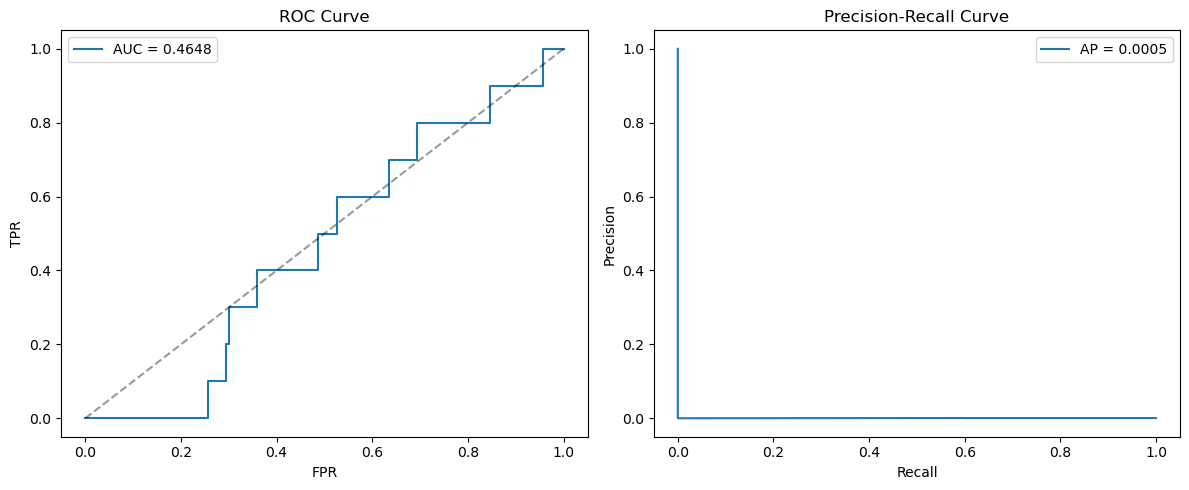

In [39]:
plot_roc_pr(
    df_ens_pred_MTOR['GI_stringent_Type2'],
    df_ens_pred_MTOR['predict_proba'])

<Axes: >

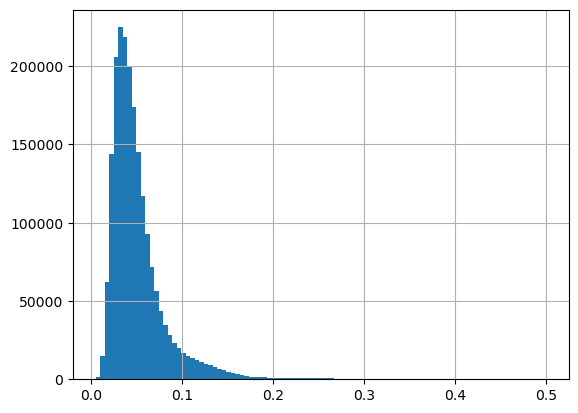

In [8]:
df_ens_pred['predict_proba'].hist(bins=100)

In [9]:
df_ens_pred['predict_proba'].nlargest(100)

1774838    0.500660
553530     0.467135
210944     0.458185
1921200    0.458135
210849     0.454559
             ...   
614363     0.355620
1805696    0.355155
1380715    0.354649
621145     0.354618
617461     0.354581
Name: predict_proba, Length: 100, dtype: float64

In [12]:
df_query_sum = pd.read_csv(heldout_direc + "query_summary_per_model.tsv", sep='\t')

In [13]:
df_query_sum

,Query,n_pairs,n_pos,pos_rate,AUROC,AUPR,AP,model
0,ABCB1,17155,10,0.000583,0.391834,0.000644,0.000644,fold_10
1,ALKBH1,17121,13,0.000759,0.572840,0.001846,0.001846,fold_10
2,APOBEC3A,17143,3,0.000175,0.474874,0.000214,0.000214,fold_10
3,APOBEC3B,17130,0,0.000000,NaN,NaN,NaN,fold_10
4,APOBEC3C,17155,44,0.002565,0.493326,0.003153,0.003153,fold_10
...,...,...,...,...,...,...,...,...
1175,VPS13A,17146,9,0.000525,0.283577,0.000454,0.000454,fold_9
1176,VPS33A,17150,52,0.003032,0.595996,0.007597,0.007597,fold_9
1177,WNK3,17130,22,0.001284,0.555609,0.001472,0.001472,fold_9
1178,WTAP,17147,9,0.000525,0.726981,0.002244,0.002244,fold_9


In [40]:
df_query_sum[df_query_sum['Query']=='MTOR']

,Query,n_pairs,n_pos,pos_rate,AUROC,AUPR,AP,model
61,MTOR,17132,10,0.000584,0.344948,0.000459,0.000459,fold_10
179,MTOR,17132,10,0.000584,0.510670,0.000677,0.000677,fold_1
297,MTOR,17132,10,0.000584,0.520109,0.000675,0.000675,fold_2
415,MTOR,17132,10,0.000584,0.292098,0.000517,0.000517,fold_3
533,MTOR,17132,10,0.000584,0.390854,0.000521,0.000521,fold_4
651,MTOR,17132,10,0.000584,0.619408,0.001167,0.001167,fold_5
769,MTOR,17132,10,0.000584,0.534464,0.001377,0.001377,fold_6
887,MTOR,17132,10,0.000584,0.290620,0.000421,0.000421,fold_7
1005,MTOR,17132,10,0.000584,0.412247,0.000556,0.000556,fold_8
1123,MTOR,17132,10,0.000584,0.563556,0.000833,0.000833,fold_9


In [41]:
df_ens_pred_MTOR[df_ens_pred_MTOR['GI_stringent_Type2']==1]

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,predict_proba
5836,GLIS1,MTOR,-0.705382,9.837123e-04,negative,negative,1,1,0,1,1,0,0.106587
5891,GNA13,MTOR,-0.618909,3.688156e-03,negative,negative,1,1,0,1,1,0,0.118340
7679,KMT2A,MTOR,-0.772548,1.086384e-04,negative,negative,1,1,0,1,1,0,0.126643
7843,LAMTOR5,MTOR,-0.853749,9.425175e-03,negative,negative,1,1,0,1,1,0,0.059426
9835,NSD1,MTOR,-0.748769,1.987989e-03,negative,negative,1,1,0,1,1,0,0.123333
10743,PDLIM7,MTOR,-0.944189,8.341334e-08,negative,negative,1,1,0,1,1,0,0.094737
12768,SAP130,MTOR,-0.807851,9.837123e-04,negative,negative,1,1,0,1,1,0,0.122948
12789,SATB2,MTOR,-0.779102,3.776207e-03,negative,negative,1,1,0,1,1,0,0.080470
14081,SRP9,MTOR,-0.678421,3.499270e-05,negative,negative,1,1,0,1,1,0,0.109184
14255,STRN4,MTOR,-0.601368,2.290747e-03,negative,negative,1,1,0,1,1,0,0.099130


In [42]:
# Check the gold version
heldout_direc = "~/DeepSLP/outputs/external_val/external_val_old_models/"

In [43]:
df_ens_pred = pd.read_csv(heldout_direc + "ensemble_predictions.tsv", sep='\t')

<Axes: >

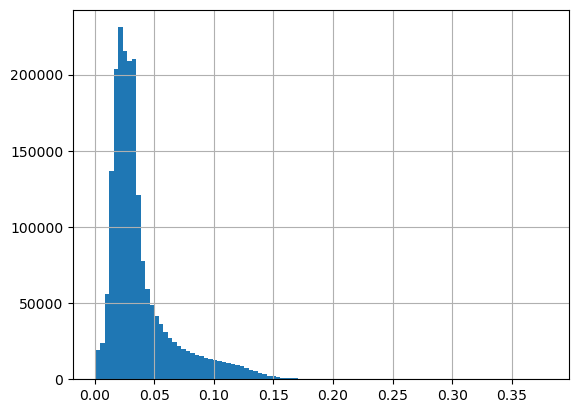

In [45]:
df_ens_pred['predict_proba'].hist(bins=100)

In [51]:
df_ens_pred.sort_values('predict_proba', ascending=False).head(100)

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,predict_proba
676638,RAB18,COG3,-1.423154,4.764774e-08,negative,negative,1,1,0,1,1,0,0.378993
704851,RAB18,COG7,-0.973700,5.568667e-04,negative,negative,1,1,0,1,1,0,0.351258
1997402,VPS52,TMED2,-0.494528,1.638005e-01,NaN,NaN,0,0,0,0,0,0,0.331522
718860,RAB18,COG8,-0.328413,8.801835e-01,NaN,NaN,0,0,0,0,0,0,0.317194
1996882,TSSC1,TMED2,-1.622183,1.030726e-13,negative,negative,1,1,0,1,1,0,0.317026
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709670,PDS5A,PFDN1,0.344959,4.371494e-01,NaN,NaN,0,0,0,0,0,0,0.234186
1822212,PTAR1,TMED2,0.041520,9.383157e-01,NaN,NaN,0,0,0,0,0,0,0.234037
703490,PAXIP1,COG7,0.198019,6.159333e-01,NaN,NaN,0,0,0,0,0,0,0.233930
1566453,MTMR9,TMED2,-0.563891,7.016412e-06,negative,NaN,1,1,0,0,0,0,0.233883


In [46]:
df_query_sum = pd.read_csv(heldout_direc + "query_summary_per_model.tsv", sep='\t')

In [47]:
df_query_sum

,Query,n_pairs,n_pos,pos_rate,AUROC,AUPR,AP,model
0,ABCB1,17155,10,0.000583,0.809020,0.016337,0.016337,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
1,ALKBH1,17121,13,0.000759,0.679282,0.001778,0.001778,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
2,APOBEC3A,17143,3,0.000175,0.691696,0.084770,0.084770,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
3,APOBEC3B,17130,0,0.000000,NaN,NaN,NaN,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
4,APOBEC3C,17155,44,0.002565,0.780234,0.008637,0.008637,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
...,...,...,...,...,...,...,...,...
1175,VPS13A,17146,9,0.000525,0.741417,0.003711,0.003711,CV2_811_GIV_NN_LR1e2_50e_p10_d01_10
1176,VPS33A,17150,52,0.003032,0.925326,0.047374,0.047374,CV2_811_GIV_NN_LR1e2_50e_p10_d01_10
1177,WNK3,17130,22,0.001284,0.753635,0.003075,0.003075,CV2_811_GIV_NN_LR1e2_50e_p10_d01_10
1178,WTAP,17147,9,0.000525,0.783010,0.014258,0.014258,CV2_811_GIV_NN_LR1e2_50e_p10_d01_10


In [48]:
df_query_sum[df_query_sum['Query']=='MTOR']

,Query,n_pairs,n_pos,pos_rate,AUROC,AUPR,AP,model
61,MTOR,17132,10,0.000584,0.807832,0.003652,0.003652,CV2_811_GIV_NN_LR1e2_50e_p10_d01_1
179,MTOR,17132,10,0.000584,0.741146,0.002284,0.002284,CV2_811_GIV_NN_LR1e2_50e_p10_d01_2
297,MTOR,17132,10,0.000584,0.844513,0.003362,0.003362,CV2_811_GIV_NN_LR1e2_50e_p10_d01_3
415,MTOR,17132,10,0.000584,0.847973,0.004180,0.004180,CV2_811_GIV_NN_LR1e2_50e_p10_d01_4
533,MTOR,17132,10,0.000584,0.808609,0.003411,0.003411,CV2_811_GIV_NN_LR1e2_50e_p10_d01_5
651,MTOR,17132,10,0.000584,0.779231,0.003546,0.003546,CV2_811_GIV_NN_LR1e2_50e_p10_d01_6
769,MTOR,17132,10,0.000584,0.776440,0.002290,0.002290,CV2_811_GIV_NN_LR1e2_50e_p10_d01_7
887,MTOR,17132,10,0.000584,0.729810,0.001749,0.001749,CV2_811_GIV_NN_LR1e2_50e_p10_d01_8
1005,MTOR,17132,10,0.000584,0.785545,0.002772,0.002772,CV2_811_GIV_NN_LR1e2_50e_p10_d01_9
1123,MTOR,17132,10,0.000584,0.752114,0.003116,0.003116,CV2_811_GIV_NN_LR1e2_50e_p10_d01_10
